In [4]:
# Importing required libraries for data analysis and visualization
import pandas as pd
import numpy as np

In [8]:
# Loading datasets using full file path
customers = pd.read_csv(r"C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 1 files\Customers.csv")
orders = pd.read_csv(r"C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 1 files\orders.csv")
items = pd.read_csv(r"C:\Users\Ravi Chandra\OneDrive\Documents\Pictures\pics\work\course task\task 1 files\order_items.csv")

In [9]:
# Displaying first 5 rows of each dataset to understand structure
customers.head(5)

,customer_id,gender,age,city,signup_date,referral_source
0,1,Female,48,Mumbai,2021-12-04 00:00:00,App
1,2,Male,18,Hyderabad,2021-06-04 00:00:00,Website
2,3,Female,52,Mumbai,2023-03-05 00:00:00,App
3,4,Male,38,Mumbai,2022-02-15 00:00:00,Website
4,5,Female,33,Hyderabad,2022-12-24 00:00:00,Agent


In [10]:
orders.head(5)

,order_id,customer_id,order_date,delivery_date,order_status,payment_mode
0,10001,183,2022-12-08 00:00:00,NaN,Returned,Card
1,10002,592,2023-06-03 00:00:00,NaN,Returned,COD
2,10003,464,2023-05-17 00:00:00,2023-05-26 00:00:00,Delivered,COD
3,10004,192,2023-06-18 00:00:00,2023-06-24 00:00:00,Delivered,COD
4,10005,310,2023-09-29 00:00:00,2023-10-04 00:00:00,Delivered,UPI


In [11]:
items.head(5)

,order_id,product_id,category,quantity,price
0,10001,466,Books,1,798
1,10002,716,Home,2,1515
2,10003,738,Home,4,1302
3,10004,155,Books,3,716
4,10004,919,Grocery,4,1166


In [13]:
# Checking data types and missing values in each dataset
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      600 non-null    int64 
 1   gender           600 non-null    object
 2   age              600 non-null    int64 
 3   city             600 non-null    object
 4   signup_date      600 non-null    object
 5   referral_source  600 non-null    object
dtypes: int64(2), object(4)
memory usage: 28.2+ KB


In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       4000 non-null   int64 
 1   customer_id    4000 non-null   int64 
 2   order_date     4000 non-null   object
 3   delivery_date  2835 non-null   object
 4   order_status   4000 non-null   object
 5   payment_mode   4000 non-null   object
dtypes: int64(2), object(4)
memory usage: 187.6+ KB


In [15]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    9896 non-null   int64 
 1   product_id  9896 non-null   int64 
 2   category    9896 non-null   object
 3   quantity    9896 non-null   int64 
 4   price       9896 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 386.7+ KB


In [16]:
# Merging orders with customers and order_items to create a single dataset
#customer_id connects "customers + orders"
#order_id connects "orders + items"

df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(items, on='order_id', how='left')

In [17]:
# Displaying merged dataset top 3 rows
df.head(3)

,order_id,customer_id,order_date,delivery_date,order_status,payment_mode,gender,age,city,signup_date,referral_source,product_id,category,quantity,price
0,10001,183,2022-12-08 00:00:00,NaN,Returned,Card,Female,20,Bangalore,2022-10-11 00:00:00,Agent,466,Books,1,798
1,10002,592,2023-06-03 00:00:00,NaN,Returned,COD,Male,44,Chennai,2021-07-27 00:00:00,Agent,716,Home,2,1515
2,10003,464,2023-05-17 00:00:00,2023-05-26 00:00:00,Delivered,COD,Male,23,Hyderabad,2022-01-16 00:00:00,App,738,Home,4,1302


In [18]:
# Converting date columns to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

In [19]:
df.head(2)

,order_id,customer_id,order_date,delivery_date,order_status,payment_mode,gender,age,city,signup_date,referral_source,product_id,category,quantity,price
0,10001,183,2022-12-08,NaT,Returned,Card,Female,20,Bangalore,2022-10-11 00:00:00,Agent,466,Books,1,798
1,10002,592,2023-06-03,NaT,Returned,COD,Male,44,Chennai,2021-07-27 00:00:00,Agent,716,Home,2,1515


In [20]:
# Filling missing delivery_date with order_date to handle null values
df['delivery_date'] = df['delivery_date'].fillna(df['order_date'])

In [21]:
df[['order_date','delivery_date']].head()

,order_date,delivery_date
0,2022-12-08,2022-12-08
1,2023-06-03,2023-06-03
2,2023-05-17,2023-05-26
3,2023-06-18,2023-06-24
4,2023-06-18,2023-06-24


In [22]:
# Calculating delivery delay in days
df['delivery_delay_days'] = (df['delivery_date'] - df['order_date']).dt.days

In [23]:
df[['order_date','delivery_date','delivery_delay_days']].head()

,order_date,delivery_date,delivery_delay_days
0,2022-12-08,2022-12-08,0
1,2023-06-03,2023-06-03,0
2,2023-05-17,2023-05-26,9
3,2023-06-18,2023-06-24,6
4,2023-06-18,2023-06-24,6


In [24]:
# Creating order_value using custom function (quantity * price)
def calculate_order_value(quantity, price):
    return quantity * price

df['order_value'] = df.apply(lambda row: calculate_order_value(row['quantity'], row['price']), axis=1)

In [25]:
df[['quantity','price','order_value']].head()

,quantity,price,order_value
0,1,798,798
1,2,1515,3030
2,4,1302,5208
3,3,716,2148
4,4,1166,4664


In [26]:
# Identifying repeat customers using lambda function
repeat_count = df['customer_id'].value_counts()

df['is_repeat_customer'] = df['customer_id'].apply(lambda x: 1 if repeat_count[x] > 1 else 0)

In [27]:
df[['customer_id','is_repeat_customer']].head(10)

,customer_id,is_repeat_customer
0,183,1
1,592,1
2,464,1
3,192,1
4,192,1
5,192,1
6,192,1
7,310,1
8,263,1
9,24,1


In [28]:
# Checking count of repeat vs non-repeat customers
df['is_repeat_customer'].value_counts()

is_repeat_customer
1    9894
0       2
Name: count, dtype: int64

In [29]:
df[df['is_repeat_customer'] == 0].head()

,order_id,customer_id,order_date,delivery_date,order_status,payment_mode,gender,age,city,signup_date,referral_source,product_id,category,quantity,price,delivery_delay_days,order_value,is_repeat_customer
17,10010,103,2024-02-02,2024-02-09,Delivered,UPI,Male,38,Mumbai,2022-09-14 00:00:00,Agent,348,Books,4,1333,7,5332,0
7698,13115,306,2024-01-06,2024-01-10,Delivered,COD,Male,39,Bangalore,2021-09-21 00:00:00,App,869,Clothing,4,318,4,1272,0


In [34]:
# Marking orders above 3000 as high value orders
df['is_high_value_order'] = df['order_value'].apply(lambda x: 1 if x > 3000 else 0)

In [35]:
df[['order_value','is_high_value_order']].head()

,order_value,is_high_value_order
0,798,0
1,3030,1
2,5208,1
3,2148,0
4,4664,1


In [36]:
# Segmenting customers into High, Medium, Low categories based on order value
# High   → > 5000  
# Medium → 2000 to 5000  
# Low    → < 2000
def segment(value):
    if value > 5000:
        return "High"
    elif value > 2000:
        return "Medium"
    else:
        return "Low"

df['customer_value_segment'] = df['order_value'].apply(segment)

In [37]:
df[['order_value','customer_value_segment']].head()

,order_value,customer_value_segment
0,798,Low
1,3030,Medium
2,5208,High
3,2148,Medium
4,4664,Medium


In [38]:
# Categorizing customer risk based on order status
# Returned   → High Risk  
# Cancelled  → Medium Risk  
# Delivered  → Low Risk  
def risk_category(status):
    if status == "Returned":
        return "High Risk"
    elif status == "Cancelled":
        return "Medium Risk"
    else:
        return "Low Risk"

df['customer_risk_category'] = df['order_status'].apply(risk_category)

In [39]:
df[['order_status','customer_risk_category']].head()

,order_status,customer_risk_category
0,Returned,High Risk
1,Returned,High Risk
2,Delivered,Low Risk
3,Delivered,Low Risk
4,Delivered,Low Risk


In [40]:
# Assigning reliability score based on order status
# Delivered  → +1  
# Returned   → -1  
# Cancelled  → -2  
df['order_reliability_score'] = df['order_status'].map({
    'Delivered': 1,
    'Returned': -1,
    'Cancelled': -2
})

In [41]:
df[['order_status','order_reliability_score']].head()

,order_status,order_reliability_score
0,Returned,-1
1,Returned,-1
2,Delivered,1
3,Delivered,1
4,Delivered,1


In [42]:
# Calculating total revenue for each city using for loop and converting result into DataFrame for better visualization
city_revenue = {}

for city in df['city'].unique():
    total_revenue = df[df['city'] == city]['order_value'].sum()
    city_revenue[city] = total_revenue

city_revenue_df = pd.DataFrame(list(city_revenue.items()), columns=['city','total_revenue'])

city_revenue_df

,city,total_revenue
0,Bangalore,6858048
1,Chennai,7222434
2,Hyderabad,5833398
3,Pune,7049230
4,Delhi,6279764
5,Mumbai,6135329


## BUSINESS QUESTION

### 1). Which customers generate high revenue but have high return rates?

In [43]:
# Calculating total revenue and number of returned orders for each customer
customer_analysis = df.groupby('customer_id').agg({
    'order_value': 'sum',
    'order_status': lambda x: (x == 'Returned').sum()
}).reset_index()

In [44]:
# Renaming columns for better clarity
customer_analysis.columns = ['customer_id', 'total_revenue', 'return_count']

In [45]:
# Identifying customers with high revenue and high return count
high_risk_customers = customer_analysis[
    (customer_analysis['total_revenue'] > 5000) & 
    (customer_analysis['return_count'] > 1)
]

In [46]:
# Displaying high risk customers
high_risk_customers.head()

,customer_id,total_revenue,return_count
0,1,86731,8
3,4,139057,10
4,5,76290,6
5,6,42727,3
6,7,70238,4


#### “These customers contribute high revenue but also have high return rates, which may lead to profit loss and indicate risky customer behavior.”

### 2). Which cities suffer most from delivery delays and revenue loss?

In [47]:
# Calculating average delivery delay and total revenue for each city
city_analysis = df.groupby('city').agg({
    'delivery_delay_days': 'mean',
    'order_value': 'sum'
}).reset_index()

In [48]:
# Sorting cities based on highest delivery delay
city_analysis = city_analysis.sort_values(by='delivery_delay_days', ascending=False)

In [49]:
# Displaying cities with highest delivery delays
city_analysis.head()

,city,delivery_delay_days,order_value
4,Mumbai,3.939661,6135329
1,Chennai,3.724958,7222434
0,Bangalore,3.628090,6858048
2,Delhi,3.595254,6279764
5,Pune,3.449919,7049230


In [50]:
# Rounding delivery delay to 2 decimal places for better readability
city_analysis['delivery_delay_days'] = city_analysis['delivery_delay_days'].round(2)

In [51]:
city_analysis.head()

,city,delivery_delay_days,order_value
4,Mumbai,3.94,6135329
1,Chennai,3.72,7222434
0,Bangalore,3.63,6858048
2,Delhi,3.60,6279764
5,Pune,3.45,7049230


#### “Mumbai and Chennai show the highest average delivery delays, indicating potential logistics inefficiencies.”

### 3). Are repeat customers actually more valuable?

In [52]:
# Comparing average order value between repeat and non-repeat customers
repeat_analysis = df.groupby('is_repeat_customer').agg({
    'order_value': 'mean'
}).reset_index()

In [57]:
repeat_analysis

,is_repeat_customer,order_value
0,0,3302.000000
1,1,3979.340914


#### “Repeat customers have a higher average order value compared to non-repeat customers, indicating they are more valuable and contribute significantly to revenue.”

### 4). Which categories appear profitable but lose revenue due to returns?

In [58]:
# Calculating total revenue and return count for each product category
category_analysis = df.groupby('category').agg({
    'order_value': 'sum',
    'order_status': lambda x: (x == 'Returned').sum()
}).reset_index()

In [59]:
# Renaming columns for better readability
category_analysis.columns = ['category', 'total_revenue', 'return_count']

In [60]:
# Sorting categories by highest revenue
category_analysis = category_analysis.sort_values(by='total_revenue', ascending=False)

In [61]:
# Displaying category-wise revenue and return count
category_analysis

,category,total_revenue,return_count
2,Electronics,7998996,371
1,Clothing,7968570,378
0,Books,7938092,326
3,Grocery,7789193,360
4,Home,7683352,351


#### “Clothing and Electronics categories generate high revenue but also have high return counts, indicating potential product quality or expectation mismatch issues leading to revenue loss.”

### 5). Which payment mode carries the highest risk?

In [62]:
# Calculating total risky orders (returned + cancelled) for each payment mode
payment_analysis = df.groupby('payment_mode').agg({
    'order_status': lambda x: ((x == 'Returned') | (x == 'Cancelled')).sum()
}).reset_index()

In [63]:
# Renaming column for clarity
payment_analysis.columns = ['payment_mode', 'risk_count']

In [64]:
# Sorting payment modes based on highest risk
payment_analysis = payment_analysis.sort_values(by='risk_count', ascending=False)

In [65]:
payment_analysis

,payment_mode,risk_count
2,UPI,1038
0,COD,960
1,Card,854


#### “UPI shows the highest number of risky transactions (returns and cancellations), indicating it carries the highest risk for the business compared to other payment modes.”

## Visualization

In [67]:
# Installing visualization libraries inside Jupyter Notebook
!pip install matplotlib seaborn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 1 Monthly Revenue Trend (Line Chart)

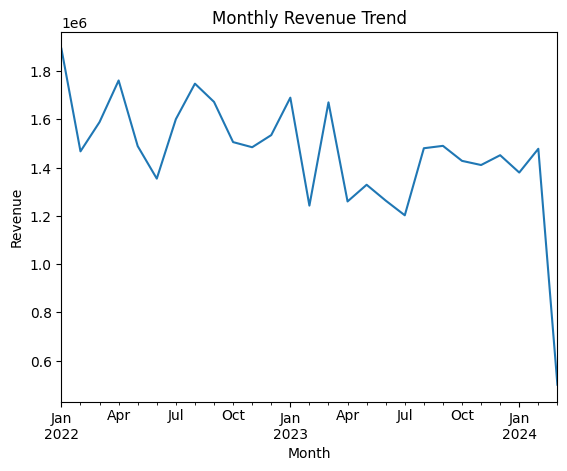

In [69]:
# Plotting monthly revenue trend to analyze sales performance over time
df['month'] = df['order_date'].dt.to_period('M')

monthly_revenue = df.groupby('month')['order_value'].sum()

monthly_revenue.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

#### “The monthly revenue trend shows fluctuations over time, with certain peak periods indicating high sales performance. A noticeable drop towards the end may indicate incomplete data or a decline in recent sales.”

### 2 Customer value segmentation – Bar chart

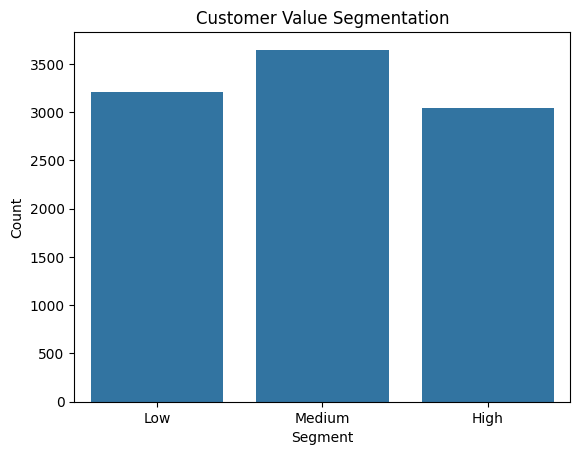

In [70]:
# Visualizing distribution of customers across value segments
sns.countplot(x='customer_value_segment', data=df)
plt.title("Customer Value Segmentation")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

#### “The majority of customers fall into the medium value segment, indicating a strong base of moderate spenders. High-value customers are fewer, suggesting an opportunity to increase premium customer engagement.”

### 3 Return rate by category – Bar chart

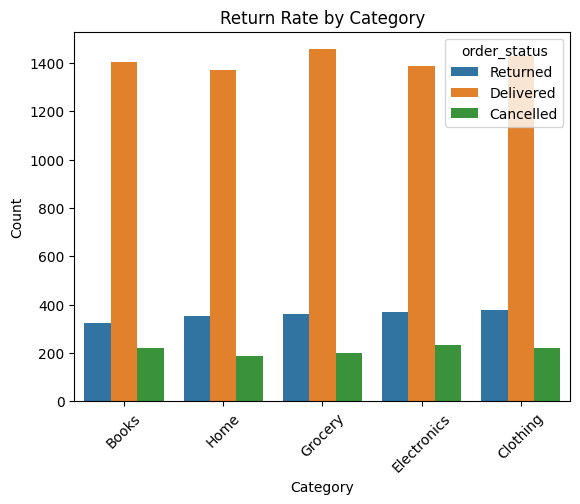

In [71]:
# Comparing returned and delivered orders across different categories
sns.countplot(x='category', hue='order_status', data=df)
plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### “Although all categories generate a high number of successful deliveries, categories like Clothing and Electronics show relatively higher return counts, indicating potential issues with product quality or customer expectations.”

### 4 Delivery delay vs revenue – Scatter plot

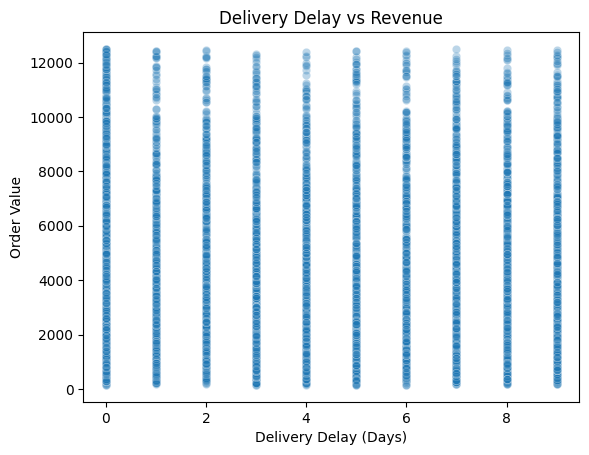

In [75]:
# Analyzing relationship between delivery delay and order value
sns.scatterplot(x='delivery_delay_days', y='order_value', data=df, alpha=0.3)
plt.title("Delivery Delay vs Revenue")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Order Value")
plt.show()

#### “The scatter plot shows no strong relationship between delivery delay and order value, indicating that delays do not significantly impact the value of orders.”

### 5 City vs category revenue – Heatmap

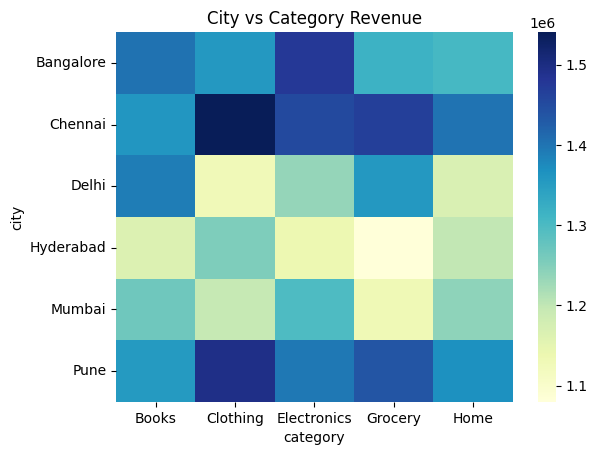

In [76]:
# Visualizing revenue distribution across cities and categories using heatmap
pivot_table = df.pivot_table(values='order_value', index='city', columns='category', aggfunc='sum')

sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title("City vs Category Revenue")
plt.show()

#### “The heatmap reveals that Chennai and Pune generate high revenue across multiple categories, especially Clothing and Grocery. In contrast, cities like Delhi and Hyderabad show relatively lower revenue, indicating opportunities for market improvement.”

## The Main 3 Business Problems

### 1. High-value customers are generating high revenue but also have high return rates, leading to profit loss.

### 2. Certain cities such as Mumbai and Chennai show higher delivery delays, affecting customer experience.

### 3. Product categories like Clothing and Electronics have high return counts despite generating high revenue.

## The 3 Data-Backed Recommendations

### 1. Improve product quality and provide accurate product descriptions to reduce return rates, especially for high-value customers.

### 2. Optimize delivery operations and logistics in high-delay cities to improve delivery performance and customer satisfaction.

### 3. Focus on quality control and customer feedback analysis in high-return categories like Clothing and Electronics to minimize revenue loss.

#### “The recommendations are based on observed patterns in customer behavior, delivery performance, and return trends identified during the analysis.”